In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path
import re
from collections import defaultdict

# Set up plotting style
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 16  # 增大全局字体大小
plt.rcParams['axes.titlesize'] = 20  # 增大子图标题字体大小
plt.rcParams['axes.labelsize'] = 18  # 增大坐标轴标签字体大小
plt.rcParams['xtick.labelsize'] = 16  # 增大x轴刻度标签字体大小
plt.rcParams['ytick.labelsize'] = 16  # 增大y轴刻度标签字体大小
plt.rcParams['legend.fontsize'] = 14  # 增大图例字体大小


# PDE_SETTINGS = [
#     "poisson_scale_k1.0_2.5_val1024_1M",
#     # "poisson_scale_k100.0_200.0_val1024_1M"  # 如果需要可以添加更多
# ]

# # eps和subsample的对应关系（根据探索结果）
# EPS_SUBSAMPLE_MAPPING = {
#     50: "subsample1",
#     75: "subsample2", 
#     100: "subsample4",
#     150: "subsample8",
#     200: "subsample16",
#     300: "subsample32",
#     500: "subsample64",
#     750: "subsample128",
#     1000: "subsample256"
# }

# Configuration
BASE_DIR = "results_all_downloaded"
PDE_SETTINGS = [
    "poisson_scale_k1.0_2.5_val1024_1M",
    "poisson_scale_k100.0_200.0_val1024_1M",
    "poisson_scale_k1.0_2.5_val1024_16M",
    "poisson_scale_k100.0_200.0_val1024_16M",
]

# eps和subsample的对应关系（根据探索结果）
EPS_SUBSAMPLE_MAPPING = {
    50: "subsample1",
    100: "subsample4",
    200: "subsample16",
    500: "subsample64",
}

SEEDS = [2021, 2022, 2023]  ##, 2024, 2025

def parse_logs_file(file_path):
    """解析logs.txt文件，提取train_err和val_err数据"""
    try:
        with open(file_path, 'r') as f:
            content = f.read()
        
        # 按空行分割，每个block是一个epoch的数据
        blocks = content.strip().split('\n\n')
        
        train_erres = []
        val_errs = []
        epochs = []
        
        for block in blocks:
            lines = block.strip().split('\n')
            epoch = None
            train_err = None
            val_err = None
            
            for line in lines:
                if line.startswith('epoch,'):
                    epoch = int(line.split(',')[1])
                elif line.startswith('tr_err,'): ###train_err
                    # 提取tensor中的数值
                    match = re.search(r'tensor\(\[([0-9.]+)\]', line)
                    if match:
                        train_err = float(match.group(1))
                elif line.startswith('val_err,'):
                    # 提取tensor中的数值
                    match = re.search(r'tensor\(\[([0-9.]+)\]', line)
                    if match:
                        val_err = float(match.group(1))
            
            if epoch is not None and train_err is not None and val_err is not None:
                epochs.append(epoch)
                train_erres.append(train_err)
                val_errs.append(val_err)
        
        return epochs, train_erres, val_errs
    
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return [], [], []

def collect_training_data():
    """收集所有训练数据"""
    data = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(dict))))
    
    for eps, subsample in EPS_SUBSAMPLE_MAPPING.items():
        step = eps // 50  # 计算epoch步长
        print(f"Processing eps{eps} -> {subsample} (step={step})")
        
        for pde_setting in PDE_SETTINGS:
            train_dir = f"{BASE_DIR}/expts_eps{eps}/{pde_setting}/train/bsz128_lr0.001_{subsample}"
            
            if not os.path.exists(train_dir):
                print(f"  Directory not found: {train_dir}")
                continue
            
            # 扫描所有seed
            for seed in SEEDS:
                seed_dir = os.path.join(train_dir, f"seed{seed}")
                logs_file = os.path.join(seed_dir, "logs.txt")
                
                if os.path.exists(logs_file):
                    epochs, train_erres, val_errs = parse_logs_file(logs_file)
                    
                    if len(epochs) > 0:
                        for epoch, train_err, val_err in zip(epochs, train_erres, val_errs):
                            data[pde_setting][subsample][epoch][seed] = {
                                'train_err': train_err,
                                'val_err': val_err
                            }
                        print(f"    seed{seed}: {len(epochs)} epochs loaded")
                    else:
                        print(f"    seed{seed}: No data found")
                else:
                    print(f"    seed{seed}: logs.txt not found")
    
    return data

# 收集数据
print("开始收集训练数据...")
training_data = collect_training_data()
print("数据收集完成！")


开始收集训练数据...
Processing eps50 -> subsample1 (step=1)
    seed2021: 50 epochs loaded
    seed2022: 50 epochs loaded
    seed2023: 50 epochs loaded
    seed2021: 50 epochs loaded
    seed2022: 50 epochs loaded
    seed2023: 50 epochs loaded
    seed2021: 50 epochs loaded
    seed2022: 50 epochs loaded
    seed2023: 50 epochs loaded
    seed2021: 50 epochs loaded
    seed2022: 50 epochs loaded
    seed2023: 50 epochs loaded
Processing eps100 -> subsample4 (step=2)
    seed2021: 100 epochs loaded
    seed2022: 100 epochs loaded
    seed2023: 100 epochs loaded
    seed2021: 100 epochs loaded
    seed2022: 100 epochs loaded
    seed2023: 100 epochs loaded
    seed2021: 100 epochs loaded
    seed2022: 100 epochs loaded
    seed2023: 100 epochs loaded
    seed2021: 100 epochs loaded
    seed2022: 100 epochs loaded
    seed2023: 100 epochs loaded
Processing eps200 -> subsample16 (step=4)
    seed2021: 200 epochs loaded
    seed2022: 200 epochs loaded
    seed2023: 200 epochs loaded
    seed2021:

In [10]:
def process_data_for_plotting(training_data, metric='train_err'):
    """处理数据用于绘图，计算每个(pde_setting, subsample, epoch)组合的均值和标准差"""
    plot_data = []
    
    for pde_setting in training_data:
        for subsample in training_data[pde_setting]:
            epochs = sorted(training_data[pde_setting][subsample].keys())
            
            for epoch in epochs:
                values = []
                for seed in SEEDS:
                    if seed in training_data[pde_setting][subsample][epoch]:
                        values.append(training_data[pde_setting][subsample][epoch][seed][metric])
                
                if len(values) > 0:
                    mean_val = np.mean(values)
                    std_val = np.std(values) if len(values) > 1 else 0
                    n_seeds = len(values)
                    
                    plot_data.append({
                        'pde_setting': pde_setting,
                        'subsample': subsample,
                        'epoch': epoch,
                        f'mean_{metric}': mean_val,
                        f'std_{metric}': std_val,
                        'n_seeds': n_seeds,
                        f'{metric}_values': values
                    })
    
    return pd.DataFrame(plot_data)

def create_training_plots(plot_df, metric='train_err'):
    """创建训练曲线可视化"""
    
    # 设置颜色映射，为不同subsample分配不同颜色
    subsamples = sorted(plot_df['subsample'].unique(), 
                       key=lambda x: int(x.replace('subsample', '')))
    colors = plt.cm.tab10(np.linspace(0, 1, len(subsamples)))
    color_map = dict(zip(subsamples, colors))
    
    # 为每种PDE设置创建子图
    fig, axes = plt.subplots(1, len(PDE_SETTINGS), figsize=(20, 8))
    if len(PDE_SETTINGS) == 1:
        axes = [axes]
    
    for i, pde_setting in enumerate(PDE_SETTINGS):
        ax = axes[i]
        
        # 过滤当前PDE设置的数据
        pde_data = plot_df[plot_df['pde_setting'] == pde_setting]
        
        for subsample in subsamples:
            subsample_data = pde_data[pde_data['subsample'] == subsample]
            
            if len(subsample_data) == 0:
                continue
                
            # 按epoch排序
            subsample_data = subsample_data.sort_values('epoch')
            
            epochs = subsample_data['epoch'].values
            means = subsample_data[f'mean_{metric}'].values
            stds = subsample_data[f'std_{metric}'].values
            
            # 画主线
            subsample_num = int(subsample.replace('subsample', ''))
            label = f'Subsample {subsample_num}'
            ax.plot(epochs, means, color=color_map[subsample], 
                   linewidth=2, marker='o', markersize=4, label=label)
            
            # 画标准差区间
            ax.fill_between(epochs, means - stds, means + stds, 
                           color=color_map[subsample], alpha=0.2)
        
        # 设置图形属性（使用更大的字体以适合会议展示）
        ax.set_xlabel('Epoch', fontsize=18)
        if metric == 'train_err':
            ax.set_ylabel('Training Error', fontsize=18)
            ax.set_title(f'Training Error vs Epoch\\n{pde_setting.replace("_", " ")}', 
                        fontsize=20, fontweight='bold')
        else:
            ax.set_ylabel('Validation Error', fontsize=18)
            ax.set_title(f'Validation Error vs Epoch\\n{pde_setting.replace("_", " ")}', 
                        fontsize=20, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=14, loc='best')
        
        # 使用log scale for y-axis 如果数据跨度很大
        if len(pde_data) > 0:
            y_range = pde_data[f'mean_{metric}'].max() / pde_data[f'mean_{metric}'].min()
            if y_range > 100:  # 如果跨度超过100倍，使用log scale
                ax.set_yscale('log')
    
    plt.tight_layout()
    plt.show()
    
    return fig

def print_data_summary(plot_df, metric='train_err'):
    """打印数据摘要"""
    print(f"\\n=== {metric.upper()} 数据摘要 ===")
    print(f"总计数据点: {len(plot_df)}")
    
    for pde_setting in PDE_SETTINGS:
        print(f"\\n{pde_setting}:")
        pde_data = plot_df[plot_df['pde_setting'] == pde_setting]
        
        for subsample in sorted(pde_data['subsample'].unique(), 
                               key=lambda x: int(x.replace('subsample', ''))):
            subsample_data = pde_data[pde_data['subsample'] == subsample]
            n_epochs = len(subsample_data)
            epoch_range = f"{subsample_data['epoch'].min()}-{subsample_data['epoch'].max()}" if n_epochs > 0 else "N/A"
            avg_seeds = subsample_data['n_seeds'].mean() if n_epochs > 0 else 0
            
            print(f"  {subsample}: {n_epochs} epochs ({epoch_range}), avg {avg_seeds:.1f} seeds per epoch")

# 处理训练损失和验证错误数据
print("处理训练数据...")
train_err_df = process_data_for_plotting(training_data, 'train_err')
val_err_df = process_data_for_plotting(training_data, 'val_err')

print_data_summary(train_err_df, 'train_err')
print_data_summary(val_err_df, 'val_err')


处理训练数据...
\n=== TRAIN_ERR 数据摘要 ===
总计数据点: 3400
\npoisson_scale_k1.0_2.5_val1024_1M:
  subsample1: 50 epochs (0-49), avg 3.0 seeds per epoch
  subsample4: 100 epochs (0-99), avg 3.0 seeds per epoch
  subsample16: 200 epochs (0-199), avg 3.0 seeds per epoch
  subsample64: 500 epochs (0-499), avg 3.0 seeds per epoch
\npoisson_scale_k100.0_200.0_val1024_1M:
  subsample1: 50 epochs (0-49), avg 3.0 seeds per epoch
  subsample4: 100 epochs (0-99), avg 3.0 seeds per epoch
  subsample16: 200 epochs (0-199), avg 3.0 seeds per epoch
  subsample64: 500 epochs (0-499), avg 3.0 seeds per epoch
\npoisson_scale_k1.0_2.5_val1024_16M:
  subsample1: 50 epochs (0-49), avg 3.0 seeds per epoch
  subsample4: 100 epochs (0-99), avg 3.0 seeds per epoch
  subsample16: 200 epochs (0-199), avg 3.0 seeds per epoch
  subsample64: 500 epochs (0-499), avg 3.0 seeds per epoch
\npoisson_scale_k100.0_200.0_val1024_16M:
  subsample1: 50 epochs (0-49), avg 3.0 seeds per epoch
  subsample4: 100 epochs (0-99), avg 3.0 seeds

\n=== 精简版可视化开始 ===
\n1. 创建核心比较图表 (1M vs 16M)...


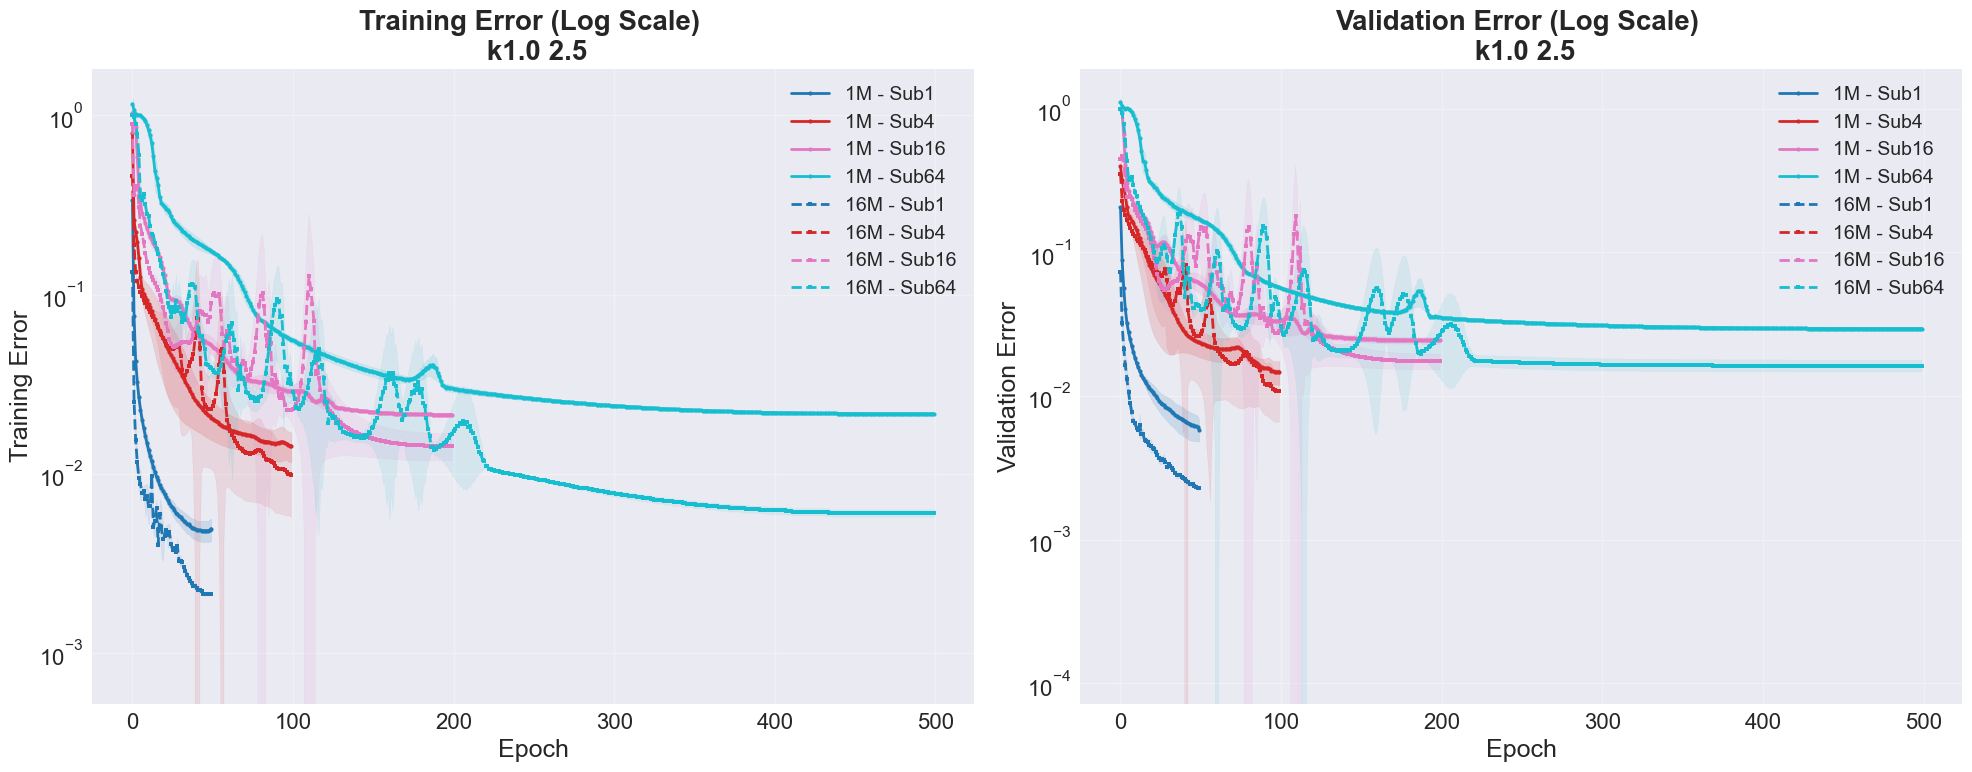

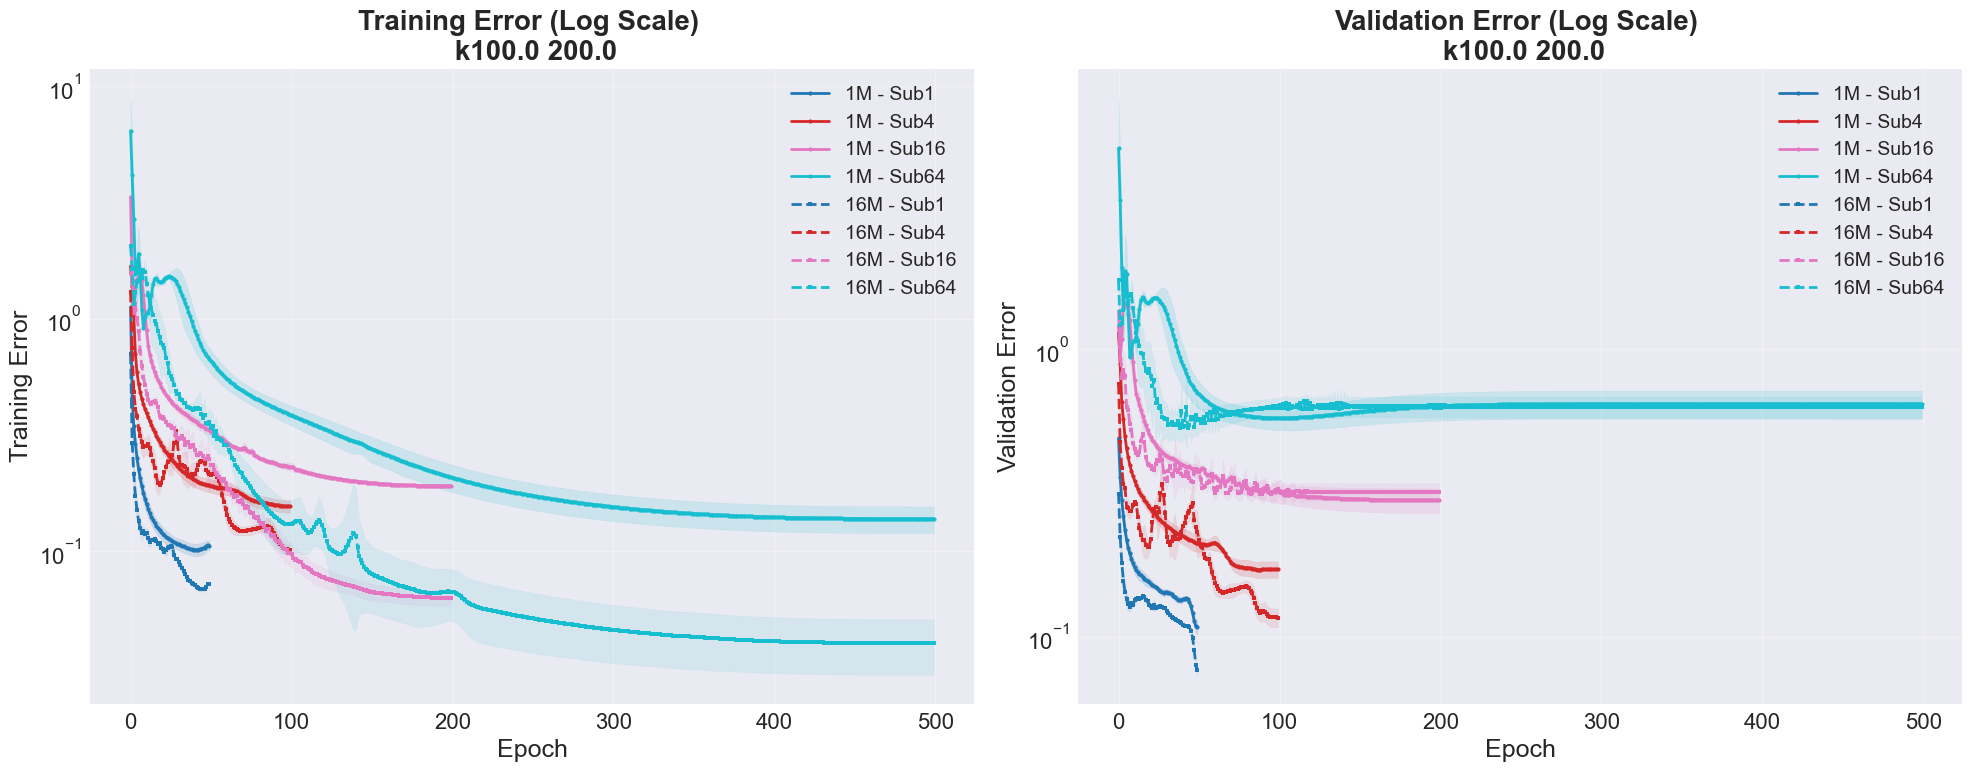

\n2. 分析最终性能...
\n=== 训练趋势分析 (精简版) ===
\npoisson scale k1.0 2.5 val1024 1M:
  subsample1 (eps=50): Train Error=0.0049, Val Error=0.0058
  subsample4 (eps=100): Train Error=0.0143, Val Error=0.0147
  subsample16 (eps=200): Train Error=0.0213, Val Error=0.0243
  subsample64 (eps=500): Train Error=0.0216, Val Error=0.0294
\npoisson scale k100.0 200.0 val1024 1M:
  subsample1 (eps=50): Train Error=0.1053, Val Error=0.1080
  subsample4 (eps=100): Train Error=0.1565, Val Error=0.1713
  subsample16 (eps=200): Train Error=0.1915, Val Error=0.2985
  subsample64 (eps=500): Train Error=0.1381, Val Error=0.6457
\npoisson scale k1.0 2.5 val1024 16M:
  subsample1 (eps=50): Train Error=0.0021, Val Error=0.0023
  subsample4 (eps=100): Train Error=0.0098, Val Error=0.0109
  subsample16 (eps=200): Train Error=0.0143, Val Error=0.0174
  subsample64 (eps=500): Train Error=0.0060, Val Error=0.0162
\npoisson scale k100.0 200.0 val1024 16M:
  subsample1 (eps=50): Train Error=0.0722, Val Error=0.0763
  subsamp

In [11]:
# =====================================
# 精简版代码 - 只生成最核心的可视化图表
# =====================================

# 简化的可视化函数，只保留最重要的比较图表
def create_essential_comparison_plots(train_err_df, val_err_df):
    """创建精简版的1M vs 16M数据集比较图（增强线形区分度和字体大小）"""
    
    # 定义PDE设置对应关系
    pde_pairs = [
        ("poisson_scale_k1.0_2.5_val1024_1M", "poisson_scale_k1.0_2.5_val1024_16M"),
        ("poisson_scale_k100.0_200.0_val1024_1M", "poisson_scale_k100.0_200.0_val1024_16M")
    ]
    
    subsamples = sorted(train_err_df['subsample'].unique(), 
                       key=lambda x: int(x.replace('subsample', '')))
    colors = plt.cm.tab10(np.linspace(0, 1, len(subsamples)))
    color_map = dict(zip(subsamples, colors))
    
    for pde_1m, pde_16m in pde_pairs:
        base_pde_name = pde_1m.replace('_val1024_1M', '').replace('poisson_scale_', '').replace('_', ' ')
        
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))
        
        # 训练损失比较 (对数尺度)
        ax1 = axes[0]
        
        # 1M数据集
        train_1m_data = train_err_df[train_err_df['pde_setting'] == pde_1m]
        for subsample in subsamples:
            subsample_data = train_1m_data[train_1m_data['subsample'] == subsample]
            if len(subsample_data) == 0:
                continue
            
            subsample_data = subsample_data.sort_values('epoch')
            epochs = subsample_data['epoch'].values
            means = subsample_data['mean_train_err'].values
            stds = subsample_data['std_train_err'].values
            
            subsample_num = int(subsample.replace('subsample', ''))
            ax1.plot(epochs, means, color=color_map[subsample], 
                    linewidth=2, marker='o', markersize=3, 
                    label=f'1M - Sub{subsample_num}', linestyle='-')
            ax1.fill_between(epochs, means - stds, means + stds, 
                           color=color_map[subsample], alpha=0.15)
        
        # 16M数据集
        train_16m_data = train_err_df[train_err_df['pde_setting'] == pde_16m]
        for subsample in subsamples:
            subsample_data = train_16m_data[train_16m_data['subsample'] == subsample]
            if len(subsample_data) == 0:
                continue
            
            subsample_data = subsample_data.sort_values('epoch')
            epochs = subsample_data['epoch'].values
            means = subsample_data['mean_train_err'].values
            stds = subsample_data['std_train_err'].values
            
            subsample_num = int(subsample.replace('subsample', ''))
            ax1.plot(epochs, means, color=color_map[subsample], 
                    linewidth=2, marker='s', markersize=3, 
                    label=f'16M - Sub{subsample_num}', linestyle='--')
            ax1.fill_between(epochs, means - stds, means + stds, 
                           color=color_map[subsample], alpha=0.1)
        
        ax1.set_xlabel('Epoch', fontsize=18)
        ax1.set_ylabel('Training Error', fontsize=18)
        ax1.set_title(f'Training Error (Log Scale) \n {base_pde_name}', fontsize=20, fontweight='bold')
        ax1.set_yscale('log')
        ax1.grid(True, alpha=0.3)
        ax1.legend(fontsize=14, loc='best')
        
        # 验证错误比较 (对数尺度)
        ax2 = axes[1]
        
        # 1M数据集
        val_1m_data = val_err_df[val_err_df['pde_setting'] == pde_1m]
        for subsample in subsamples:
            subsample_data = val_1m_data[val_1m_data['subsample'] == subsample]
            if len(subsample_data) == 0:
                continue
            
            subsample_data = subsample_data.sort_values('epoch')
            epochs = subsample_data['epoch'].values
            means = subsample_data['mean_val_err'].values
            stds = subsample_data['std_val_err'].values
            
            subsample_num = int(subsample.replace('subsample', ''))
            ax2.plot(epochs, means, color=color_map[subsample], 
                    linewidth=2, marker='o', markersize=3, 
                    label=f'1M - Sub{subsample_num}', linestyle='-')
            ax2.fill_between(epochs, means - stds, means + stds, 
                           color=color_map[subsample], alpha=0.15)
        
        # 16M数据集
        val_16m_data = val_err_df[val_err_df['pde_setting'] == pde_16m]
        for subsample in subsamples:
            subsample_data = val_16m_data[val_16m_data['subsample'] == subsample]
            if len(subsample_data) == 0:
                continue
            
            subsample_data = subsample_data.sort_values('epoch')
            epochs = subsample_data['epoch'].values
            means = subsample_data['mean_val_err'].values
            stds = subsample_data['std_val_err'].values
            
            subsample_num = int(subsample.replace('subsample', ''))
            ax2.plot(epochs, means, color=color_map[subsample], 
                    linewidth=2, marker='s', markersize=3, 
                    label=f'16M - Sub{subsample_num}', linestyle='--')
            ax2.fill_between(epochs, means - stds, means + stds, 
                           color=color_map[subsample], alpha=0.1)
        
        ax2.set_xlabel('Epoch', fontsize=18)
        ax2.set_ylabel('Validation Error', fontsize=18)
        ax2.set_title(f'Validation Error (Log Scale) \n {base_pde_name}', fontsize=20, fontweight='bold')
        ax2.set_yscale('log')
        ax2.grid(True, alpha=0.3)
        ax2.legend(fontsize=14, loc='best')
        
        plt.tight_layout()
        plt.show()
    
    return fig

def simplified_analyze_trends(train_err_df, val_err_df):
    """简化的训练趋势分析"""
    print("\\n=== 训练趋势分析 (精简版) ===")
    
    for pde_setting in PDE_SETTINGS:
        print(f"\\n{pde_setting.replace('_', ' ')}:")
        
        train_pde_data = train_err_df[train_err_df['pde_setting'] == pde_setting]
        val_pde_data = val_err_df[val_err_df['pde_setting'] == pde_setting]
        
        for subsample in sorted(train_pde_data['subsample'].unique(), 
                               key=lambda x: int(x.replace('subsample', ''))):
            train_subsample_data = train_pde_data[train_pde_data['subsample'] == subsample].sort_values('epoch')
            val_subsample_data = val_pde_data[val_pde_data['subsample'] == subsample].sort_values('epoch')
            
            if len(train_subsample_data) < 2 or len(val_subsample_data) < 2:
                continue
                
            # 最终性能
            final_train_err = train_subsample_data.iloc[-1]['mean_train_err']
            final_val_err = val_subsample_data.iloc[-1]['mean_val_err']
            
            eps = [k for k, v in EPS_SUBSAMPLE_MAPPING.items() if v == subsample][0]
            
            print(f"  {subsample} (eps={eps}): Train Error={final_train_err:.4f}, Val Error={final_val_err:.4f}")

# =====================================
# 执行精简版可视化
# =====================================

print("\\n=== 精简版可视化开始 ===")
print("\\n1. 创建核心比较图表 (1M vs 16M)...")
essential_fig = create_essential_comparison_plots(train_err_df, val_err_df)

print("\\n2. 分析最终性能...")
simplified_analyze_trends(train_err_df, val_err_df)

print("\\n=== 精简版可视化完成！===")
print("\\n总共生成图表数: 2个PDE设置 × 1个图表 = 2个图表")
print("每个图表包含: 训练损失对比 + 验证错误对比")


In [12]:
# =====================================
# 创建结果总结表格
# =====================================

def create_results_summary_table(train_err_df, val_err_df):
    """创建训练结果的总结表格"""
    
    # 收集数据
    results_data = []
    
    for pde_setting in PDE_SETTINGS:
        train_pde_data = train_err_df[train_err_df['pde_setting'] == pde_setting]
        val_pde_data = val_err_df[val_err_df['pde_setting'] == pde_setting]
        
        # 简化PDE设置名称
        if 'k1.0_2.5' in pde_setting and '1M' in pde_setting:
            pde_name = 'k=1.0-2.5, 1M'
        elif 'k100.0_200.0' in pde_setting and '1M' in pde_setting:
            pde_name = 'k=100-200, 1M'
        elif 'k1.0_2.5' in pde_setting and '16M' in pde_setting:
            pde_name = 'k=1.0-2.5, 16M'
        elif 'k100.0_200.0' in pde_setting and '16M' in pde_setting:
            pde_name = 'k=100-200, 16M'
        else:
            pde_name = pde_setting
        
        for subsample in sorted(train_pde_data['subsample'].unique(), 
                               key=lambda x: int(x.replace('subsample', ''))):
            train_subsample_data = train_pde_data[train_pde_data['subsample'] == subsample].sort_values('epoch')
            val_subsample_data = val_pde_data[val_pde_data['subsample'] == subsample].sort_values('epoch')
            
            if len(train_subsample_data) > 0 and len(val_subsample_data) > 0:
                # 最终性能（最后一个epoch）
                final_train_err = train_subsample_data.iloc[-1]['mean_train_err']
                final_val_err = val_subsample_data.iloc[-1]['mean_val_err']
                
                # 获取对应的eps值
                eps = [k for k, v in EPS_SUBSAMPLE_MAPPING.items() if v == subsample][0]
                subsample_num = int(subsample.replace('subsample', ''))
                
                results_data.append({
                    'PDE Setting': pde_name,
                    'Subsample': f'Sub{subsample_num}',
                    'EPS': eps,
                    'Final Train Error': f'{final_train_err:.4f}',
                    'Final Val Error': f'{final_val_err:.4f}'
                })
    
    # 创建DataFrame
    results_df = pd.DataFrame(results_data)
    
    # 显示表格
    print("\\n" + "="*80)
    print("训练结果总结表格")
    print("="*80)
    
    # 按PDE设置分组显示
    for pde_name in results_df['PDE Setting'].unique():
        pde_subset = results_df[results_df['PDE Setting'] == pde_name]
        print(f"\\n{pde_name}:")
        print("-" * 60)
        
        # 创建子表格（不包含PDE Setting列）
        display_df = pde_subset[['Subsample', 'EPS', 'Final Train Error', 'Final Val Error']].reset_index(drop=True)
        
        # 美化表格显示
        print(display_df.to_string(index=False, justify='center'))
    
    print("\\n" + "="*80)
    
    return results_df

def create_comparison_table(train_err_df, val_err_df):
    """创建1M vs 16M的对比表格"""
    
    print("\\n" + "="*90)
    print("1M vs 16M 参数对比表格")
    print("="*90)
    
    # 定义对比对
    comparison_pairs = [
        ('k=1.0-2.5', 'poisson_scale_k1.0_2.5_val1024_1M', 'poisson_scale_k1.0_2.5_val1024_16M'),
        ('k=100-200', 'poisson_scale_k100.0_200.0_val1024_1M', 'poisson_scale_k100.0_200.0_val1024_16M')
    ]
    
    for k_range, pde_1m, pde_16m in comparison_pairs:
        print(f"\\n{k_range} 参数范围:")
        print("-" * 70)
        
        comparison_data = []
        
        # 获取1M和16M的数据
        train_1m_data = train_err_df[train_err_df['pde_setting'] == pde_1m]
        val_1m_data = val_err_df[val_err_df['pde_setting'] == pde_1m]
        train_16m_data = train_err_df[train_err_df['pde_setting'] == pde_16m]
        val_16m_data = val_err_df[val_err_df['pde_setting'] == pde_16m]
        
        subsamples = sorted(train_1m_data['subsample'].unique(), 
                           key=lambda x: int(x.replace('subsample', '')))
        
        for subsample in subsamples:
            # 1M数据
            train_1m_sub = train_1m_data[train_1m_data['subsample'] == subsample].sort_values('epoch')
            val_1m_sub = val_1m_data[val_1m_data['subsample'] == subsample].sort_values('epoch')
            
            # 16M数据
            train_16m_sub = train_16m_data[train_16m_data['subsample'] == subsample].sort_values('epoch')
            val_16m_sub = val_16m_data[val_16m_data['subsample'] == subsample].sort_values('epoch')
            
            if len(train_1m_sub) > 0 and len(val_1m_sub) > 0 and len(train_16m_sub) > 0 and len(val_16m_sub) > 0:
                eps = [k for k, v in EPS_SUBSAMPLE_MAPPING.items() if v == subsample][0]
                subsample_num = int(subsample.replace('subsample', ''))
                
                comparison_data.append({
                    'Subsample': f'Sub{subsample_num}',
                    'EPS': eps,
                    '1M Train Error': f'{train_1m_sub.iloc[-1]["mean_train_err"]:.4f}',
                    '1M Val Error': f'{val_1m_sub.iloc[-1]["mean_val_err"]:.4f}',
                    '16M Train Error': f'{train_16m_sub.iloc[-1]["mean_train_err"]:.4f}',
                    '16M Val Error': f'{val_16m_sub.iloc[-1]["mean_val_err"]:.4f}'
                })
        
        # 显示对比表格
        comparison_df = pd.DataFrame(comparison_data)
        print(comparison_df.to_string(index=False, justify='center'))
    
    print("\\n" + "="*90)
    
    return comparison_df

# 生成表格
print("正在生成结果表格...")
results_table = create_results_summary_table(train_err_df, val_err_df)
comparison_table = create_comparison_table(train_err_df, val_err_df)


正在生成结果表格...
\n================================================================================
训练结果总结表格
\nk=1.0-2.5, 1M:
------------------------------------------------------------
Subsample  EPS Final Train Error Final Val Error
   Sub1    50        0.0049           0.0058    
   Sub4   100        0.0143           0.0147    
  Sub16   200        0.0213           0.0243    
  Sub64   500        0.0216           0.0294    
\nk=100-200, 1M:
------------------------------------------------------------
Subsample  EPS Final Train Error Final Val Error
   Sub1    50        0.1053           0.1080    
   Sub4   100        0.1565           0.1713    
  Sub16   200        0.1915           0.2985    
  Sub64   500        0.1381           0.6457    
\nk=1.0-2.5, 16M:
------------------------------------------------------------
Subsample  EPS Final Train Error Final Val Error
   Sub1    50        0.0021           0.0023    
   Sub4   100        0.0098           0.0109    
  Sub16   200        0.0